In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/final_mobile_dataset.csv')

In [3]:
df.head()

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size(Inches),Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Android,IOS,Version,Price
0,MediaTek,OnePlus,8,128,7100,6.77,AMOLED,120,50.0,16.0,1,0,15,22999
1,Snapdragon,vivo,8,128,6000,6.77,AMOLED,120,50.0,50.0,1,0,15,34999
2,MediaTek,realme,8,256,7000,6.78,AMOLED,120,50.0,32.0,1,0,15,39998
3,MediaTek,POCO,8,256,6550,6.67,AMOLED,120,50.0,20.0,1,0,15,23998
4,Samsung,Samsung,8,128,5000,6.70,AMOLED,120,50.0,12.0,1,0,15,38999


In [4]:
df['Price'].unique()

array([ 22999,  34999,  39998,  23998,  38999,  20290,  49999, 117999,
        13999,  42997,  16220,  19270,  11999,  16199,  19999,  26999,
         9998,  54998,  16999,  29999,  31999,  22998,  27999,  82490,
        25650,  52489,  17999,  87400,  29750,  92999,  30999,  27694,
        12849,  20748,  25999,  23999,  16499,  10574,  23563,  15999,
        22939,  10560,  18999,  48999,  18998,  11798,  72900,  28999,
       133900,  14999,  11499,  17996,  17799,  22399,  37340,  17499,
        27998,  22209,  57900,  21748,  65999,   9499,  30990,  17998,
        20990,  11180,  15120,  34998,   9498,  35999,  23980,  20999,
        10499,  99999,  39999,  43900,  29990,  19599,  18465,  18749,
        64998, 109999,  22490,  21710,  32999,  15910,  50999,  51997,
        12999,  45739,  25990,   7999,  37999, 110900,  14398,   7689,
       174999,  69999,  10899,  72222,  11973,  36999,  31500,  15499,
        12998,  54990,  24999,  87999,   8939,  12499,  22990,  19805,
      

## Пояснение к данным
    1. Processor - процессор телефона
    2. Brand - брэнд телефона
    3. Ram_GB - оперативная память телефона
    4. Rom_GB - память телефона
    5. Battery_Capacity - размер батареи
    6. Display_Size - размер экрана в дюймах
    7. Display_Quality - тип экрана
    8. Refresh_Rate - частота обновления экрана
    9. Rear_Camera_MP - разрешение задней, основной камеры
    10. Front_Camera_MP - разрешение передней камеры
    11. Android, IOS - операционная система телефона
    12. Version - версия операционной системы
    13. Price - цена которую надо предсказать (в рупиях)

## ВСЯ РАБОТА

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Processor             1056 non-null   object 
 1   Brand                 1056 non-null   object 
 2   Ram_GB                1056 non-null   int64  
 3   Rom_GB                1056 non-null   int64  
 4   Battery_Capacity      1056 non-null   int64  
 5   Display_Size(Inches)  1056 non-null   float64
 6   Display_Quality       1056 non-null   object 
 7   Refresh_Rate          1056 non-null   int64  
 8   Rear_Camera_MP        1047 non-null   float64
 9   Front_Camera_MP       1047 non-null   float64
 10  Android               1056 non-null   int64  
 11  IOS                   1056 non-null   int64  
 12  Version               1056 non-null   int64  
 13  Price                 1056 non-null   int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 115.6+ KB


In [6]:
df = df.rename(columns={'Display_Size(Inches)' : 'Display_Size'})

In [7]:
df.head()

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size,Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Android,IOS,Version,Price
0,MediaTek,OnePlus,8,128,7100,6.77,AMOLED,120,50.0,16.0,1,0,15,22999
1,Snapdragon,vivo,8,128,6000,6.77,AMOLED,120,50.0,50.0,1,0,15,34999
2,MediaTek,realme,8,256,7000,6.78,AMOLED,120,50.0,32.0,1,0,15,39998
3,MediaTek,POCO,8,256,6550,6.67,AMOLED,120,50.0,20.0,1,0,15,23998
4,Samsung,Samsung,8,128,5000,6.70,AMOLED,120,50.0,12.0,1,0,15,38999


In [8]:
def create_column(row):
    if row['IOS'] == 1:
        return 'IOS'
    elif row['Android'] == 1:
        return 'Android'
    return 'Other'

In [9]:
df['OpSys'] = df.apply(create_column, axis=1)

In [10]:
df = df.drop(['Android', 'IOS'], axis=1)

In [11]:
df.head()

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size,Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Version,Price,OpSys
0,MediaTek,OnePlus,8,128,7100,6.77,AMOLED,120,50.0,16.0,15,22999,Android
1,Snapdragon,vivo,8,128,6000,6.77,AMOLED,120,50.0,50.0,15,34999,Android
2,MediaTek,realme,8,256,7000,6.78,AMOLED,120,50.0,32.0,15,39998,Android
3,MediaTek,POCO,8,256,6550,6.67,AMOLED,120,50.0,20.0,15,23998,Android
4,Samsung,Samsung,8,128,5000,6.70,AMOLED,120,50.0,12.0,15,38999,Android


In [12]:
df['OpSys'].unique()

array(['Android', 'IOS'], dtype=object)

In [13]:
df['Price'] = (df['Price'] / 87).round(2)

In [14]:
df.head()

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size,Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Version,Price,OpSys
0,MediaTek,OnePlus,8,128,7100,6.77,AMOLED,120,50.0,16.0,15,264.36,Android
1,Snapdragon,vivo,8,128,6000,6.77,AMOLED,120,50.0,50.0,15,402.29,Android
2,MediaTek,realme,8,256,7000,6.78,AMOLED,120,50.0,32.0,15,459.75,Android
3,MediaTek,POCO,8,256,6550,6.67,AMOLED,120,50.0,20.0,15,275.84,Android
4,Samsung,Samsung,8,128,5000,6.70,AMOLED,120,50.0,12.0,15,448.26,Android


In [15]:
df['Price'].unique()

array([ 264.36,  402.29,  459.75,  275.84,  448.26,  233.22,  574.7 ,
       1356.31,  160.91,  494.22,  186.44,  221.49,  137.92,  186.2 ,
        229.87,  310.33,  114.92,  632.16,  195.39,  344.82,  367.8 ,
        264.34,  321.83,  948.16,  294.83,  603.32,  206.89, 1004.6 ,
        341.95, 1068.95,  356.31,  318.32,  147.69,  238.48,  298.84,
        275.85,  189.64,  121.54,  270.84,  183.9 ,  263.67,  121.38,
        218.38,  563.21,  218.37,  135.61,  837.93,  333.32, 1539.08,
        172.4 ,  132.17,  206.85,  204.59,  257.46,  429.2 ,  201.14,
        321.82,  255.28,  665.52,  249.98,  758.61,  109.18,  356.21,
        206.87,  241.26,  128.51,  173.79,  402.28,  109.17,  413.78,
        275.63,  241.37,  120.68, 1149.41,  459.76,  504.6 ,  344.71,
        225.28,  212.24,  215.51,  747.1 , 1264.36,  258.51,  249.54,
        379.3 ,  182.87,  586.2 ,  597.67,  149.41,  525.74,  298.74,
         91.94,  436.77, 1274.71,  165.49,   88.38, 2011.48,  804.59,
        125.28,  830

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Processor         1056 non-null   object 
 1   Brand             1056 non-null   object 
 2   Ram_GB            1056 non-null   int64  
 3   Rom_GB            1056 non-null   int64  
 4   Battery_Capacity  1056 non-null   int64  
 5   Display_Size      1056 non-null   float64
 6   Display_Quality   1056 non-null   object 
 7   Refresh_Rate      1056 non-null   int64  
 8   Rear_Camera_MP    1047 non-null   float64
 9   Front_Camera_MP   1047 non-null   float64
 10  Version           1056 non-null   int64  
 11  Price             1056 non-null   float64
 12  OpSys             1056 non-null   object 
dtypes: float64(4), int64(5), object(4)
memory usage: 107.4+ KB


In [17]:
df.isnull().sum()

Processor           0
Brand               0
Ram_GB              0
Rom_GB              0
Battery_Capacity    0
Display_Size        0
Display_Quality     0
Refresh_Rate        0
Rear_Camera_MP      9
Front_Camera_MP     9
Version             0
Price               0
OpSys               0
dtype: int64

In [18]:
df['Rear_Camera_MP'] = df['Rear_Camera_MP'].fillna(df['Rear_Camera_MP'].median())

In [19]:
df['Front_Camera_MP'] = df['Front_Camera_MP'].fillna(df['Front_Camera_MP'].median())

In [20]:
df.isnull().sum()

Processor           0
Brand               0
Ram_GB              0
Rom_GB              0
Battery_Capacity    0
Display_Size        0
Display_Quality     0
Refresh_Rate        0
Rear_Camera_MP      0
Front_Camera_MP     0
Version             0
Price               0
OpSys               0
dtype: int64

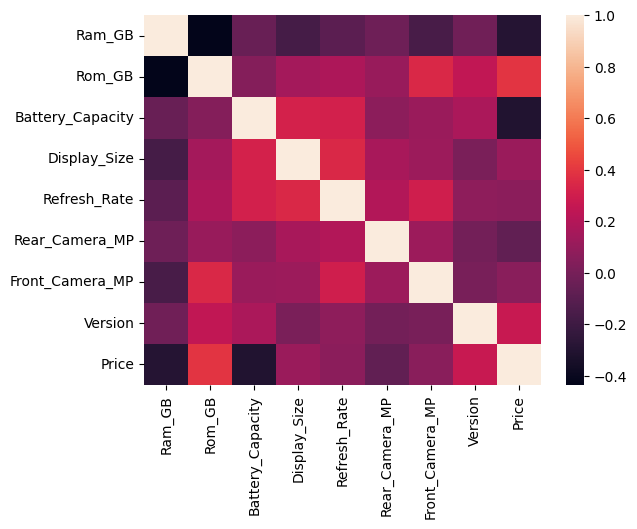

In [21]:
sns.heatmap(df.corr(numeric_only=True));

<Axes: xlabel='Price', ylabel='Version'>

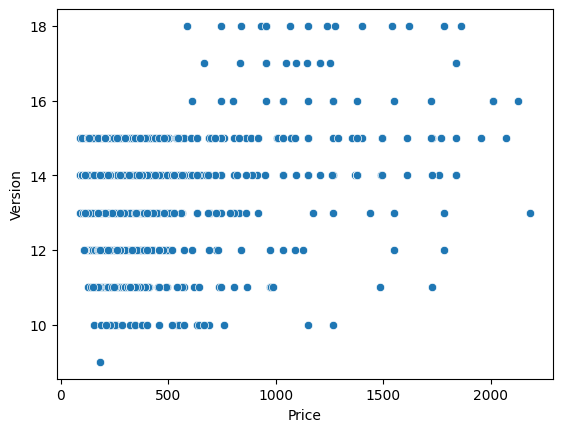

In [22]:
sns.scatterplot(x='Price', y='Version', data=df)

In [23]:
df[(df['Version'] == 13) & (df['Price'] > 2000)]

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size,Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Version,Price,OpSys
1005,Snapdragon,Galaxy,1,1,4400,7.6,AMOLED,120,50.0,4.0,13,2183.9,Android


In [24]:
df = df.drop(1005)

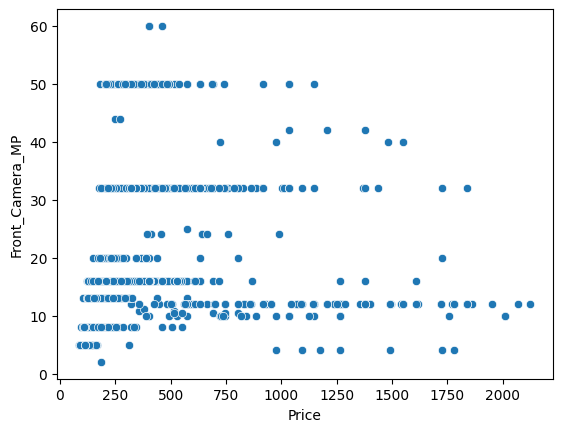

In [25]:
sns.scatterplot(x='Price', y='Front_Camera_MP', data=df);

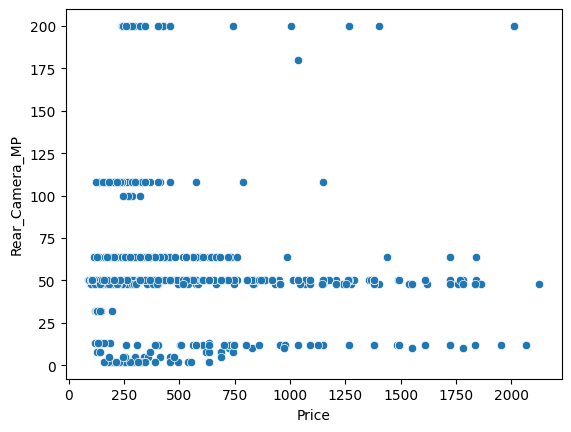

In [26]:
sns.scatterplot(x='Price', y='Rear_Camera_MP', data=df);

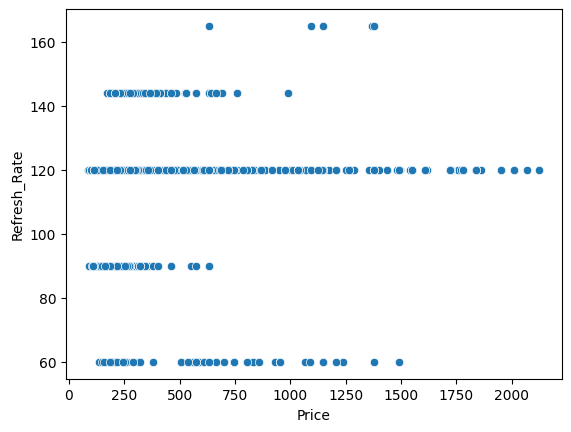

In [27]:
sns.scatterplot(x='Price', y='Refresh_Rate', data=df);

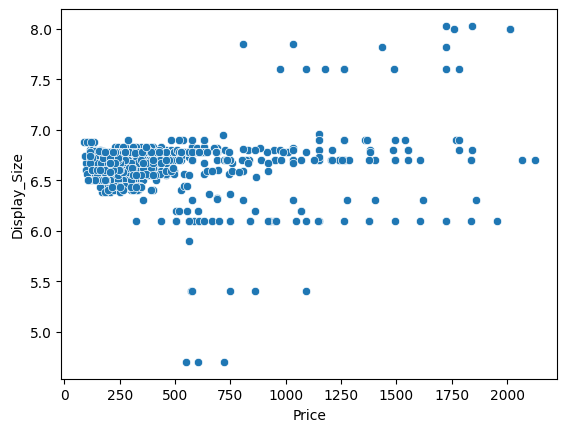

In [28]:
sns.scatterplot(x='Price', y='Display_Size', data=df);

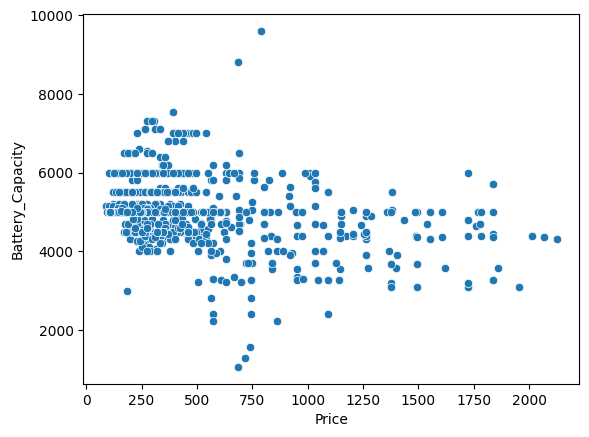

In [29]:
sns.scatterplot(x='Price', y='Battery_Capacity', data=df);

In [30]:
df[df['Battery_Capacity'] > 8_000]

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size,Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Version,Price,OpSys
1045,MediaTek,Ulefone,1,512,9600,6.58,LCD,120,108.0,32.0,13,787.36,Android
1052,MediaTek,Blackview,1,512,8800,6.78,LCD,120,50.0,50.0,13,686.78,Android


In [31]:
df = df.drop([5, 2])

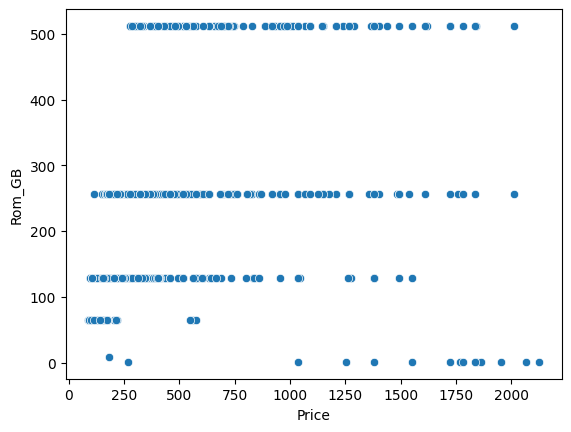

In [32]:
sns.scatterplot(x='Price', y='Rom_GB', data=df);

In [33]:
df.loc[(df['Rom_GB'] < 10) & (df['Price'] > 1000), 'Rom_GB'] = 1024

In [34]:
df[(df['Rom_GB'] > 1000) & (df['Price'] > 1000)]

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size,Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Version,Price,OpSys
188,Snapdragon,OnePlus,2,1024,6000,6.82,AMOLED,120,50.0,32.0,15,1034.45,Android
437,Snapdragon,Samsung,1,1024,5000,6.90,AMOLED,120,50.0,12.0,15,1770.10,Android
524,Snapdragon,Samsung,1,1024,5000,6.80,AMOLED,120,50.0,12.0,14,1839.07,Android
636,Snapdragon,Samsung,1,1024,5000,6.80,AMOLED,120,10.0,40.0,12,1551.71,Android
639,Apple,Apple,8,1024,3582,6.30,LCD,120,48.0,12.0,18,1860.92,IOS
661,Snapdragon,Samsung,1,1024,5000,6.80,AMOLED,120,10.0,12.0,13,1781.60,Android
677,Apple,Apple,8,1024,3274,6.10,LCD,120,48.0,12.0,17,1837.92,IOS
871,Snapdragon,OnePlus,1,1024,4805,7.82,AMOLED,120,64.0,32.0,14,1724.11,Android
909,Apple,Apple,8,1024,4441,6.70,LCD,120,48.0,12.0,17,1252.86,IOS
957,Apple,Apple,6,1024,4323,6.70,LCD,120,48.0,12.0,16,2125.29,IOS


In [35]:
df[(df['Rom_GB'] > 1000) & (df['Price'] > 1000) & (df['Ram_GB'] <= 2)]

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size,Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Version,Price,OpSys
188,Snapdragon,OnePlus,2,1024,6000,6.82,AMOLED,120,50.0,32.0,15,1034.45,Android
437,Snapdragon,Samsung,1,1024,5000,6.90,AMOLED,120,50.0,12.0,15,1770.10,Android
524,Snapdragon,Samsung,1,1024,5000,6.80,AMOLED,120,50.0,12.0,14,1839.07,Android
636,Snapdragon,Samsung,1,1024,5000,6.80,AMOLED,120,10.0,40.0,12,1551.71,Android
661,Snapdragon,Samsung,1,1024,5000,6.80,AMOLED,120,10.0,12.0,13,1781.60,Android
871,Snapdragon,OnePlus,1,1024,4805,7.82,AMOLED,120,64.0,32.0,14,1724.11,Android
1048,Snapdragon,Asus,2,1024,5500,6.78,AMOLED,165,50.0,32.0,14,1379.30,Android


In [36]:
df = df.drop([188, 437, 524, 636, 661, 871, 1048])

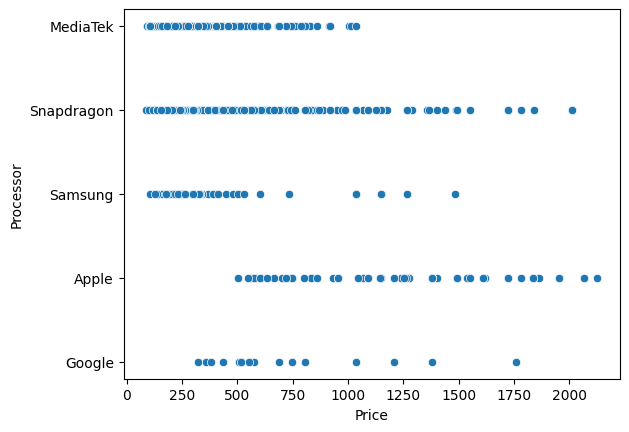

In [37]:
sns.scatterplot(x='Price', y='Processor', data=df);

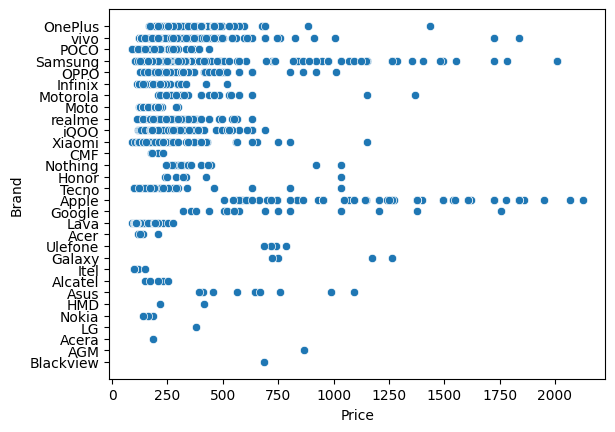

In [38]:
sns.scatterplot(x='Price', y='Brand', data=df);

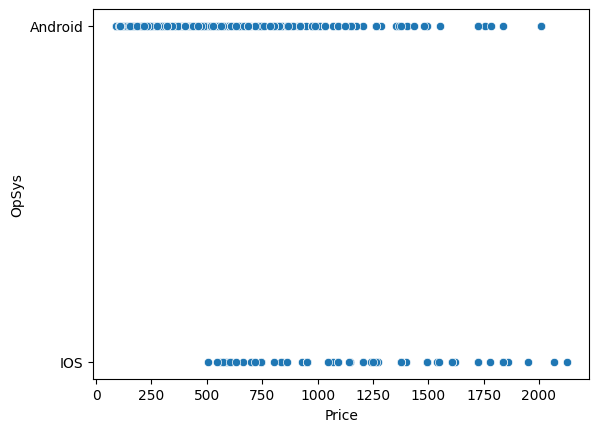

In [39]:
sns.scatterplot(x='Price', y='OpSys', data=df);

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
X = df.drop('Price', axis=1)

In [42]:
y = df['Price']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [44]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [45]:
num_features

['Ram_GB',
 'Rom_GB',
 'Battery_Capacity',
 'Display_Size',
 'Refresh_Rate',
 'Rear_Camera_MP',
 'Front_Camera_MP',
 'Version']

In [46]:
cat_features

['Processor', 'Brand', 'Display_Quality', 'OpSys']

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ],
    remainder='passthrough'
)

In [48]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', ElasticNetCV(cv=10, l1_ratio=[.1, .5, .7,.9, .95, .99, 1], n_jobs=-1))
])

In [49]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [50]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [51]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 0.5711681527768845
Лучшее значение l1_ratio: 1.0


In [52]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

In [53]:
MAE

73.01672360752252

In [54]:
MSE

12083.050167481206

In [55]:
RMSE

np.float64(109.92292830652396)

In [56]:
r2_train

0.904714602851039

In [57]:
r2_test

0.8977386715517146

In [58]:
df['Price'].mean()

np.float64(392.76310707456975)

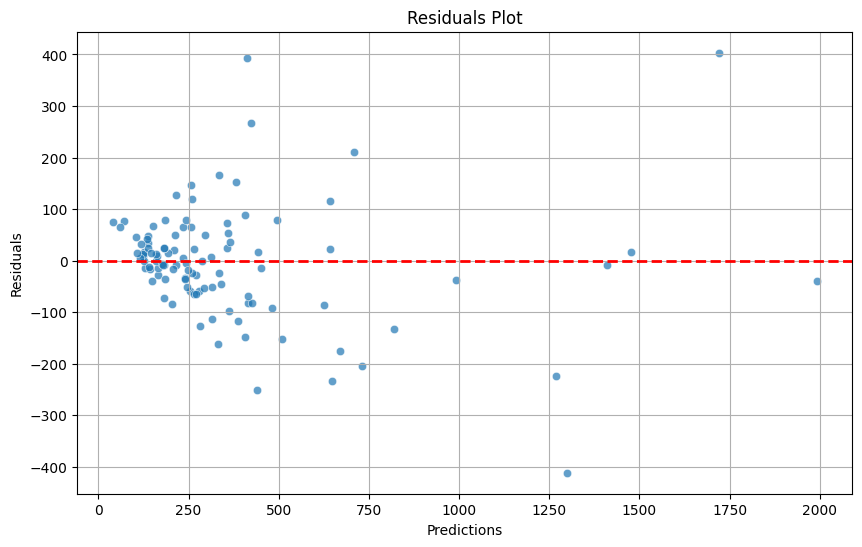

In [59]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

In [60]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [61]:
y_pred_full = pipe.predict(X)

In [62]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 0.5564472355799097
Лучшее значение l1_ratio: 1.0


In [63]:
r2_full = r2_score(y, y_pred_full)

In [64]:
r2_full

0.905138995029018

In [65]:
df.head()

,Processor,Brand,Ram_GB,Rom_GB,Battery_Capacity,Display_Size,Display_Quality,Refresh_Rate,Rear_Camera_MP,Front_Camera_MP,Version,Price,OpSys
0,MediaTek,OnePlus,8,128,7100,6.77,AMOLED,120,50.0,16.0,15,264.36,Android
1,Snapdragon,vivo,8,128,6000,6.77,AMOLED,120,50.0,50.0,15,402.29,Android
3,MediaTek,POCO,8,256,6550,6.67,AMOLED,120,50.0,20.0,15,275.84,Android
4,Samsung,Samsung,8,128,5000,6.70,AMOLED,120,50.0,12.0,15,448.26,Android
6,MediaTek,OPPO,1,256,6200,6.83,LCD,120,50.0,50.0,15,574.70,Android


In [66]:
df['Brand'].unique()

array(['OnePlus', 'vivo', 'POCO', 'Samsung', 'OPPO', 'Infinix',
       'Motorola', 'Moto', 'realme', 'iQOO', 'Xiaomi', 'CMF', 'Nothing',
       'Honor', 'Tecno', 'Apple', 'Google', 'Lava', 'Acer', 'Ulefone',
       'Galaxy', 'Itel', 'Alcatel', 'Asus', 'HMD', 'Nokia', 'LG', 'Acera',
       'AGM', 'Blackview'], dtype=object)

In [67]:
df['Processor'].unique()

array(['MediaTek', 'Snapdragon', 'Samsung', 'Apple', 'Google'],
      dtype=object)

In [68]:
df['Display_Quality'].unique()

array(['AMOLED', 'LCD'], dtype=object)

In [69]:
final_test_df = pd.DataFrame({
    'Brand': ['POCO', 'Lava'],
    'Processor': ['Snapdragon', 'MediaTek'],
    'Ram_GB': [12.0, 8.0],
    'Rom_GB': [512.0, 64.0],
    'Battery_Capacity': [6000.0, 5000.0],
    'Display_Size': [6.67, 6.50],
    'Display_Quality': ['AMOLED', 'LCD'],
    'Refresh_Rate': [120.0, 90.0],
    'Rear_Camera_MP': [50.0, 13.0],
    'Front_Camera_MP': [20.0, 8.0],
    'Version': [16.0, 13.0],
    'OpSys': ['Android', 'Android']
})

predicted_prices = pipe.predict(final_test_df)

print(f"1. POCO (12/512 ГБ): ${predicted_prices[0]:.2f}")
print(f"2. Lava (4/64 ГБ): ${predicted_prices[1]:.2f}")

1. POCO (12/512 ГБ): $349.01
2. Lava (4/64 ГБ): $126.74


In [70]:
test_df = pd.DataFrame({
    'Brand': ['Apple', 'Samsung'],
    'Processor': ['Apple', 'Snapdragon'],
    'Ram_GB': [6.0, 8.0],
    'Rom_GB': [256.0, 128.0],
    'Battery_Capacity': [4323.0, 5000.0],
    'Display_Size': [6.70, 6.50],
    'Display_Quality': ['LCD', 'AMOLED'],
    'Refresh_Rate': [120.0, 120.0],
    'Rear_Camera_MP': [48.0, 50.0],
    'Front_Camera_MP': [12.0, 13.0],
    'Version': [16.0, 14.0],
    'OpSys': ['IOS', 'Android']
})

perfect_predictions = pipe.predict(test_df)

print(f"1. iPhone (6/256 ГБ): ${perfect_predictions[0]:.2f}")
print(f"2. Samsung (8/128 ГБ): ${perfect_predictions[1]:.2f}")

1. iPhone (6/256 ГБ): $1493.13
2. Samsung (8/128 ГБ): $343.49


In [71]:
import json
import os

advanced_report = {
    "project": "Mobile Phone Price Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_Phone_Prices": df['Price'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [72]:
from joblib import dump, load

In [73]:
dump(pipe, 'model/mobile_phone_price_prediction_elastic_net_cv_2026_v1.pkl')

['model/mobile_phone_price_prediction_elastic_net_cv_2026_v1.pkl']

In [74]:
loaded_pipe = load('model/mobile_phone_price_prediction_elastic_net_cv_2026_v1.pkl')

In [75]:
loaded_pipe.predict(test_df)

array([1493.13031147,  343.48580909])